In [ ]:
# Core data science and numerical libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress runtime warnings for a clean presentation
warnings.filterwarnings('ignore')

# Set global plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Scikit-Learn tools for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries successfully loaded and environment configured!")

Libraries successfully loaded and environment configured!


In [ ]:
# Load dataset from workspace CSV file
csv_filename = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(csv_filename)

print(f"Dataset successfully loaded: {df.shape[0]} rows (records) and {df.shape[1]} columns (features).\n")
print("First 5 records of the dataset:")
print(df.head())

Dataset successfully loaded: 1470 rows (records) and 35 columns (features).

First 5 records of the dataset:
   Age Attrition  ... YearsSinceLastPromotion  YearsWithCurrManager
0   41       Yes  ...                       0                     5
1   49        No  ...                       1                     7
2   37       Yes  ...                       0                     0
3   33        No  ...                       3                     0
4   27        No  ...                       2                     2

[5 rows x 35 columns]


In [ ]:
# Display dataset column information and memory usage
print("--- Dataset Information & Column Types ---")
df.info()

--- Dataset Information & Column Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-

In [ ]:
# Display descriptive summary statistics for numerical attributes
print("--- Descriptive Statistics of Key Numerical Features ---")
print(df[['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
          'YearsInCurrentRole', 'YearsSinceLastPromotion', 'WorkLifeBalance',
          'JobSatisfaction', 'PerformanceRating']].describe().T)

--- Descriptive Statistics of Key Numerical Features ---
                          count         mean  ...     75%      max
Age                      1470.0    36.923810  ...    43.0     60.0
MonthlyIncome            1470.0  6502.931293  ...  8379.0  19999.0
TotalWorkingYears        1470.0    11.279592  ...    15.0     40.0
YearsAtCompany           1470.0     7.008163  ...     9.0     40.0
YearsInCurrentRole       1470.0     4.229252  ...     7.0     18.0
YearsSinceLastPromotion  1470.0     2.187755  ...     3.0     15.0
WorkLifeBalance          1470.0     2.761224  ...     3.0      4.0
JobSatisfaction          1470.0     2.728571  ...     4.0      4.0
PerformanceRating        1470.0     3.153741  ...     3.0      4.0

[9 rows x 8 columns]


In [ ]:
# 1. Check for missing values
null_count = df.isnull().sum().sum()
print(f"Total Missing Values in Dataset: {null_count}")

# 2. Check for duplicate rows
dup_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {dup_count}")

# 3. Drop constant and identifier columns
zero_variance_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_cleaned = df.drop(columns=[col for col in zero_variance_cols if col in df.columns])

print(f"\nFeatures before cleaning: {df.shape[1]}")
print(f"Features after cleaning : {df_cleaned.shape[1]} (Dropped: {zero_variance_cols})")

Total Missing Values in Dataset: 0
Total Duplicate Rows: 0

Features before cleaning: 35
Features after cleaning : 31 (Dropped: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'])


In [ ]:
# Compute composite workforce demand score
score = np.zeros(len(df_cleaned))
score += (df_cleaned['OverTime'] == 'Yes').astype(float) * 2.0
score += (df_cleaned['Attrition'] == 'Yes').astype(float) * 2.5
score += (df_cleaned['WorkLifeBalance'] <= 2).astype(float) * 1.5
score += (df_cleaned['YearsSinceLastPromotion'] >= 4).astype(float) * 1.0
score += (df_cleaned['PerformanceRating'] >= 4).astype(float) * 1.0
score += (df_cleaned['BusinessTravel'] == 'Travel_Frequently').astype(float) * 1.0
score += (df_cleaned['JobSatisfaction'] <= 2).astype(float) * 1.0

# Discretize score into Low Demand, Medium Demand, and High Demand
def categorize_demand(s):
    if s <= 1.5:
        return 'Low Demand'
    elif s <= 3.5:
        return 'Medium Demand'
    else:
        return 'High Demand'

df_cleaned['Workforce_Demand'] = [categorize_demand(s) for s in score]

# Display target class distribution
demand_summary = pd.DataFrame({
    'Count': df_cleaned['Workforce_Demand'].value_counts(),
    'Percentage (%)': (df_cleaned['Workforce_Demand'].value_counts(normalize=True) * 100).round(2)
})

print("--- Workforce Demand Target Distribution ---")
print(demand_summary)

--- Workforce Demand Target Distribution ---
                  Count  Percentage (%)
Workforce_Demand                       
Low Demand          618           42.04
Medium Demand       541           36.80
High Demand         311           21.16


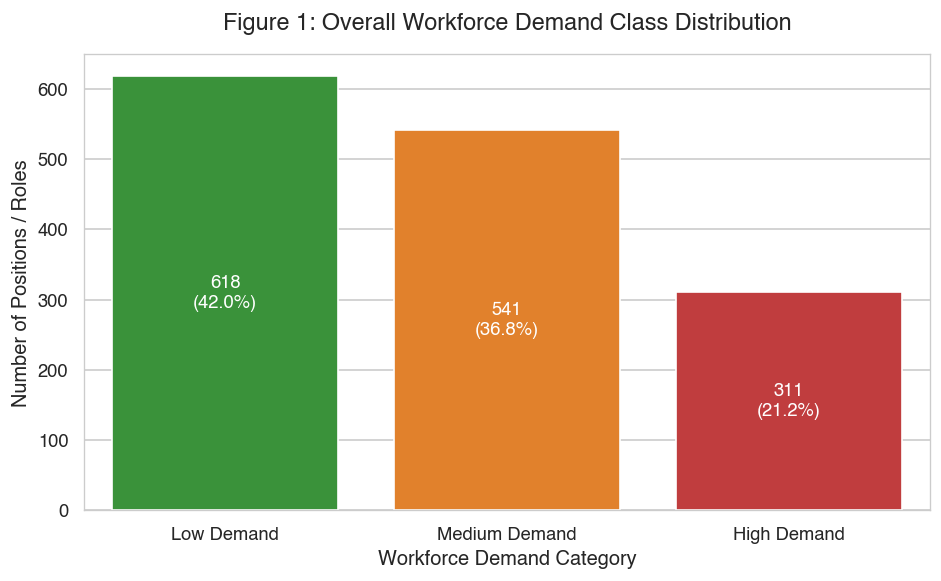

In [ ]:
# Visualization 1: Target Class Distribution
plt.figure(figsize=(8, 5))
colors = ['#2ca02c', '#ff7f0e', '#d62728'] # Green (Low), Orange (Medium), Red (High)
order = ['Low Demand', 'Medium Demand', 'High Demand']

ax = sns.countplot(data=df_cleaned, x='Workforce_Demand', order=order, palette=colors)
plt.title('Figure 1: Overall Workforce Demand Class Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Workforce Demand Category', fontsize=12)
plt.ylabel('Number of Positions / Roles', fontsize=12)

# Annotate counts and percentages on bars
total_rows = len(df_cleaned)
for p in ax.patches:
    height = p.get_height()
    pct = (height / total_rows) * 100
    ax.annotate(f'{int(height)}\n({pct:.1f}%)',
                xy=(p.get_x() + p.get_width() / 2, height / 2),
                ha='center', va='center', color='white', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

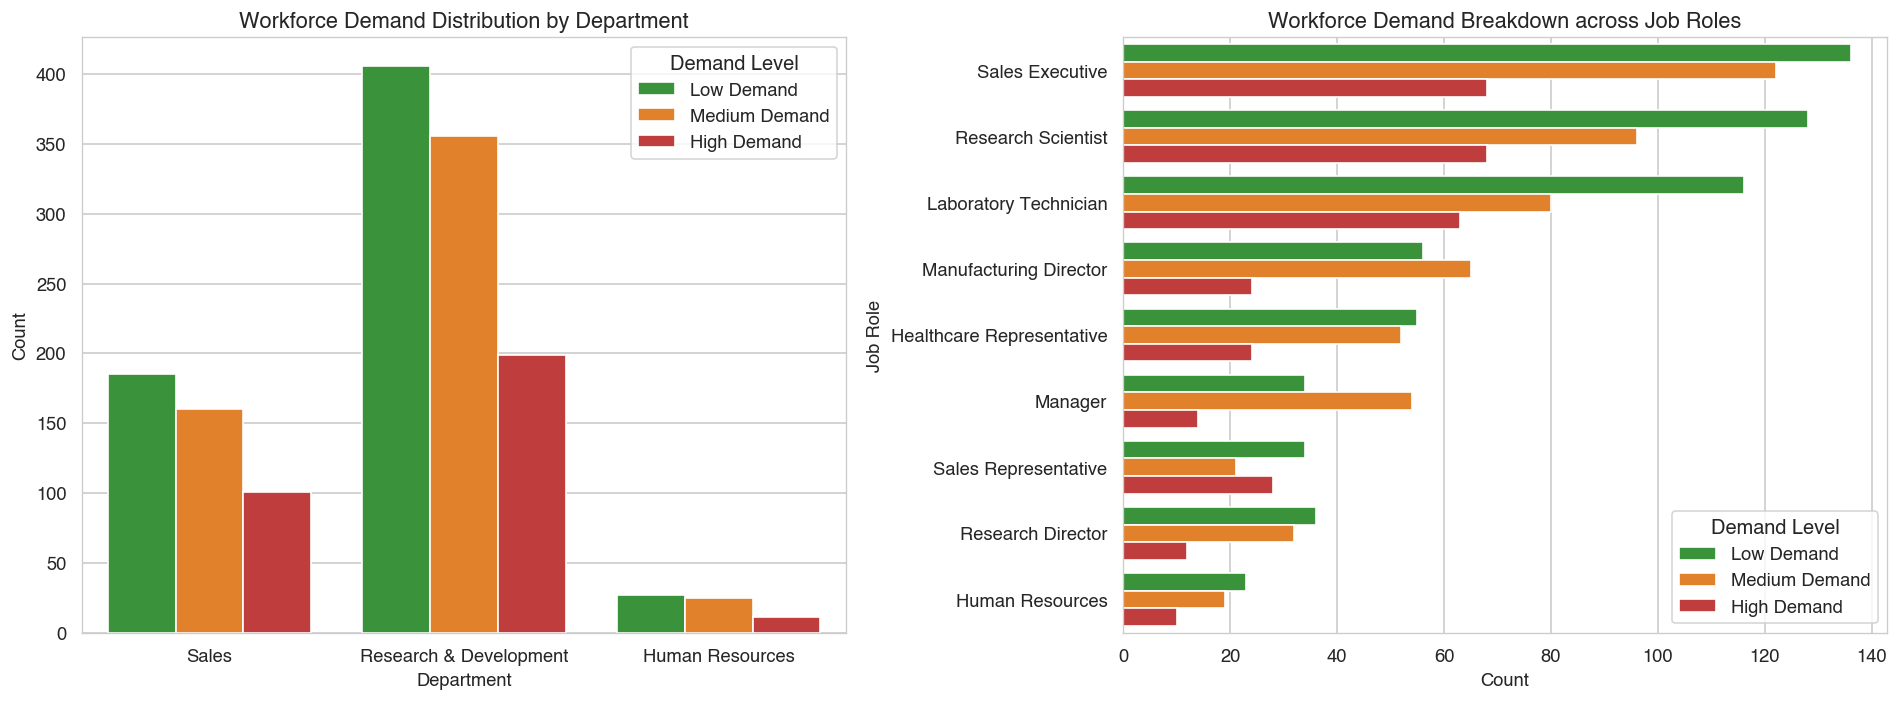

In [ ]:
# Visualization 2 & 3: Workforce Demand across Departments and Job Roles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot A: Demand by Department
sns.countplot(data=df_cleaned, x='Department', hue='Workforce_Demand',
              hue_order=['Low Demand', 'Medium Demand', 'High Demand'],
              palette=['#2ca02c', '#ff7f0e', '#d62728'], ax=axes[0])
axes[0].set_title('Workforce Demand Distribution by Department', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Department', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(title='Demand Level')

# Subplot B: Demand by Job Role
sns.countplot(data=df_cleaned, y='JobRole', hue='Workforce_Demand',
              hue_order=['Low Demand', 'Medium Demand', 'High Demand'],
              palette=['#2ca02c', '#ff7f0e', '#d62728'], ax=axes[1])
axes[1].set_title('Workforce Demand Breakdown across Job Roles', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=11)
axes[1].set_ylabel('Job Role', fontsize=11)
axes[1].legend(title='Demand Level', loc='lower right')

plt.tight_layout()
plt.show()

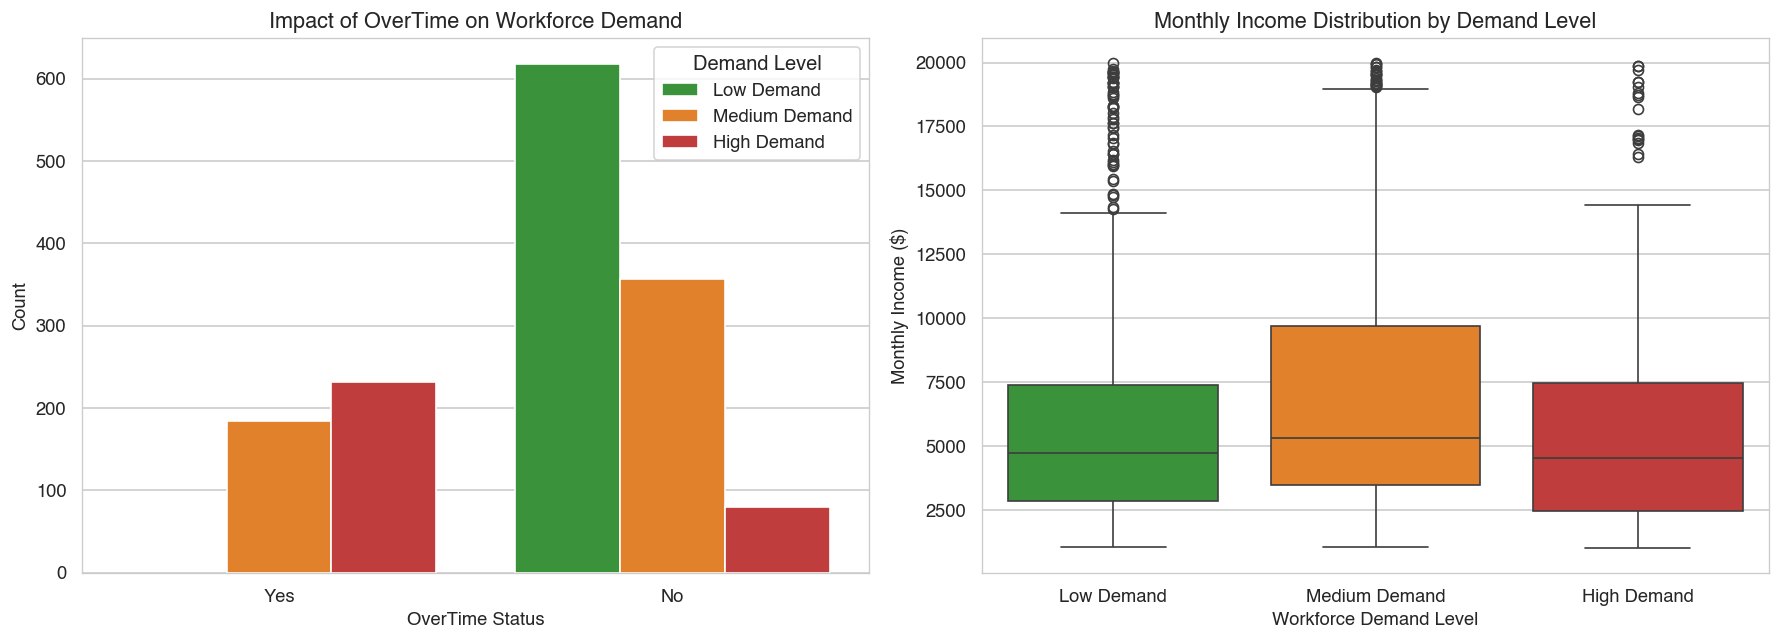

In [ ]:
# Visualization 4 & 5: Impact of OverTime and Compensation Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Subplot A: Overtime vs Workforce Demand
sns.countplot(data=df_cleaned, x='OverTime', hue='Workforce_Demand',
              hue_order=['Low Demand', 'Medium Demand', 'High Demand'],
              palette=['#2ca02c', '#ff7f0e', '#d62728'], ax=axes[0])
axes[0].set_title('Impact of OverTime on Workforce Demand', fontsize=13, fontweight='bold')
axes[0].set_xlabel('OverTime Status', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(title='Demand Level')

# Subplot B: Monthly Income Distribution across Demand Levels
sns.boxplot(data=df_cleaned, x='Workforce_Demand', y='MonthlyIncome',
            order=['Low Demand', 'Medium Demand', 'High Demand'],
            palette=['#2ca02c', '#ff7f0e', '#d62728'], ax=axes[1])
axes[1].set_title('Monthly Income Distribution by Demand Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Workforce Demand Level', fontsize=11)
axes[1].set_ylabel('Monthly Income ($)', fontsize=11)

plt.tight_layout()
plt.show()

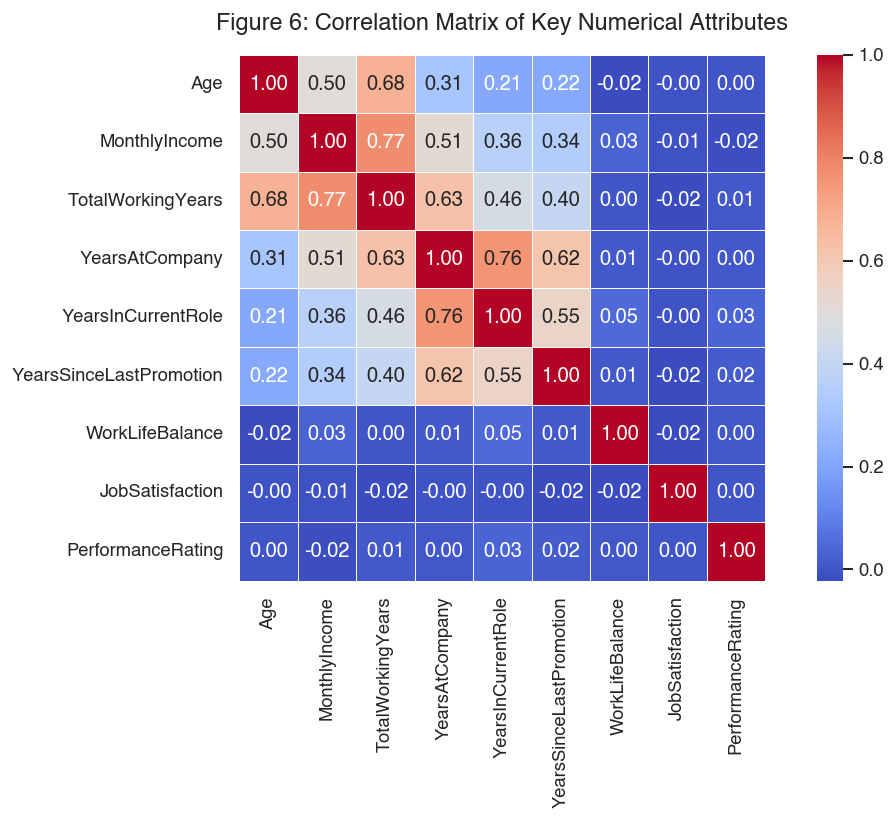

In [ ]:
# Visualization 6: Correlation Heatmap of Numerical Features
plt.figure(figsize=(10, 7))
numeric_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                'YearsInCurrentRole', 'YearsSinceLastPromotion', 'WorkLifeBalance',
                'JobSatisfaction', 'PerformanceRating']

corr = df_cleaned[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, square=True, linewidths=0.5)
plt.title('Figure 6: Correlation Matrix of Key Numerical Attributes', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Separate Feature Matrix X and Target Vector y
X = df_cleaned.drop(columns=['Workforce_Demand'])
y = df_cleaned['Workforce_Demand']

# 2. Identify categorical columns and apply One-Hot Encoding
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical Features ({len(categorical_columns)}): {categorical_columns}")

X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=True)
print(f"Total Features after One-Hot Encoding: {X_encoded.shape[1]}")

# 3. Stratified 80:20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining Matrix Shape: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing Matrix Shape : X_test  = {X_test.shape},  y_test  = {y_test.shape}")

# 4. Feature Standardization using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("StandardScaler fitted on training features and applied successfully.")

Categorical Features (8): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Total Features after One-Hot Encoding: 45

Training Matrix Shape: X_train = (1176, 45), y_train = (1176,)
Testing Matrix Shape : X_test  = (294, 45),  y_test  = (294,)
StandardScaler fitted on training features and applied successfully.


---
### 8. Training & Evaluating All 4 Machine Learning Models

As specified in the case study guidelines, we train and evaluate strictly:
1. **Logistic Regression** (Multi-class with Softmax loss)
2. **K-Nearest Neighbors (KNN)** (Distance-based neighbor classification, $k=5$)
3. **Decision Tree Classifier** (Interpretable tree with max_depth=6)
4. **Random Forest Classifier** (Bagging ensemble of 100 decision trees)

#### Evaluation Protocol:
For each model, we compute:
- **Accuracy**
- **Weighted Precision**
- **Weighted Recall**
- **Weighted F1-Score**
- **Confusion Matrix** (Heatmap Visualization)
- **Detailed Classification Report**

In [ ]:
# Helper function to evaluate and plot confusion matrix for each model
results_tracker = []
model_dict = {}
classes = ['High Demand', 'Low Demand', 'Medium Demand']

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    results_tracker.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f"==================================================")
    print(f"          MODEL: {name.upper()}")
    print(f"==================================================")
    print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}\n")

    print("--- Detailed Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(5.5, 4.2))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                cbar=False, annot_kws={'size': 12, 'weight': 'bold'})
    plt.title(f'Confusion Matrix: {name}', fontsize=12, fontweight='bold', pad=10)
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('Actual Label', fontsize=11)
    plt.tight_layout()
    plt.show()
    print("\n")

          MODEL: LOGISTIC REGRESSION
Accuracy : 0.8912 (89.12%)
Precision: 0.8911
Recall   : 0.8912
F1-Score : 0.8910

--- Detailed Classification Report ---
               precision    recall  f1-score   support

  High Demand       0.93      0.90      0.92        62
   Low Demand       0.90      0.93      0.91       124
Medium Demand       0.86      0.84      0.85       108

     accuracy                           0.89       294
    macro avg       0.90      0.89      0.89       294
 weighted avg       0.89      0.89      0.89       294





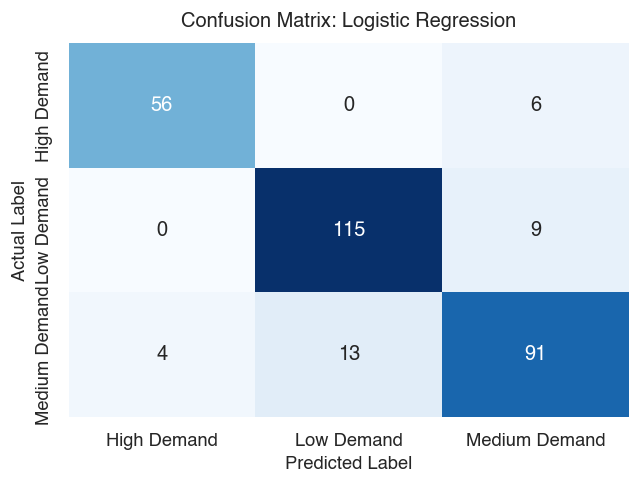

In [ ]:
# ==========================================
# 1. LOGISTIC REGRESSION
# ==========================================
# Fits multinomial logistic regression on standardized features
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
model_dict['Logistic Regression'] = lr_model

evaluate_model('Logistic Regression', y_test, y_pred_lr)

          MODEL: KNN
Accuracy : 0.5918 (59.18%)
Precision: 0.5991
Recall   : 0.5918
F1-Score : 0.5732

--- Detailed Classification Report ---
               precision    recall  f1-score   support

  High Demand       0.73      0.44      0.55        62
   Low Demand       0.59      0.85      0.69       124
Medium Demand       0.54      0.39      0.45       108

     accuracy                           0.59       294
    macro avg       0.62      0.56      0.56       294
 weighted avg       0.60      0.59      0.57       294





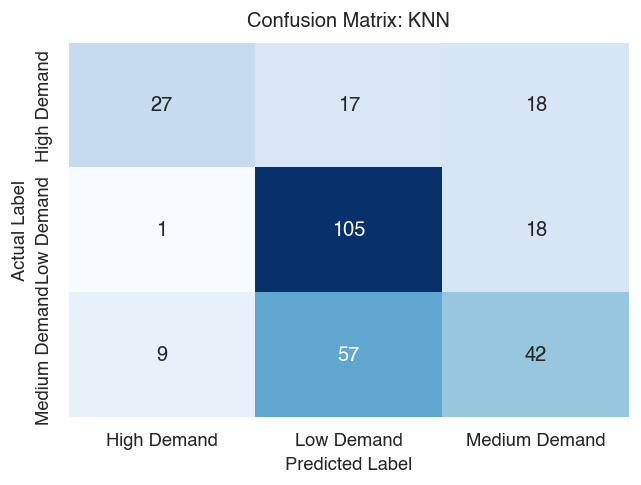

In [ ]:
# ==========================================
# 2. K-NEAREST NEIGHBORS (KNN)
# ==========================================
# Fits KNN with k=5 using Euclidean (Minkowski p=2) distance
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
model_dict['KNN'] = knn_model

evaluate_model('KNN', y_test, y_pred_knn)

          MODEL: DECISION TREE
Accuracy : 0.8844 (88.44%)
Precision: 0.8833
Recall   : 0.8844
F1-Score : 0.8819

--- Detailed Classification Report ---
               precision    recall  f1-score   support

  High Demand       0.82      0.82      0.82        62
   Low Demand       0.91      1.00      0.95       124
Medium Demand       0.89      0.79      0.83       108

     accuracy                           0.88       294
    macro avg       0.87      0.87      0.87       294
 weighted avg       0.88      0.88      0.88       294





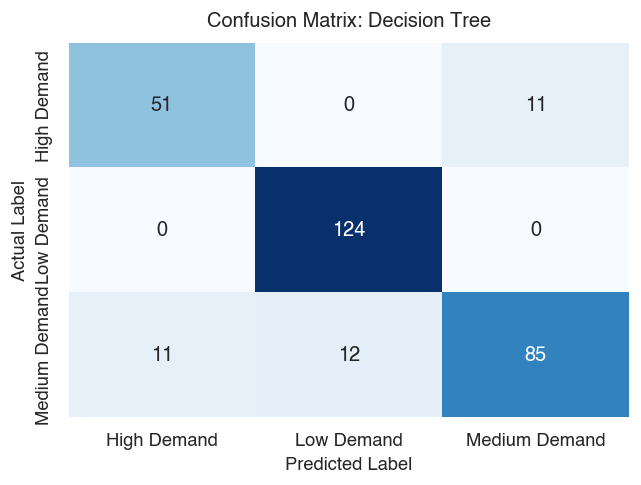

In [ ]:
# ==========================================
# 3. DECISION TREE CLASSIFIER
# ==========================================
# Fits decision tree with max_depth=6 to balance complexity and interpretability
dt_model = DecisionTreeClassifier(max_depth=6, criterion='gini', random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
model_dict['Decision Tree'] = dt_model

evaluate_model('Decision Tree', y_test, y_pred_dt)

          MODEL: RANDOM FOREST
Accuracy : 0.9082 (90.82%)
Precision: 0.9136
Recall   : 0.9082
F1-Score : 0.9064

--- Detailed Classification Report ---
               precision    recall  f1-score   support

  High Demand       0.96      0.73      0.83        62
   Low Demand       0.96      0.98      0.97       124
Medium Demand       0.83      0.94      0.88       108

     accuracy                           0.91       294
    macro avg       0.92      0.88      0.89       294
 weighted avg       0.91      0.91      0.91       294





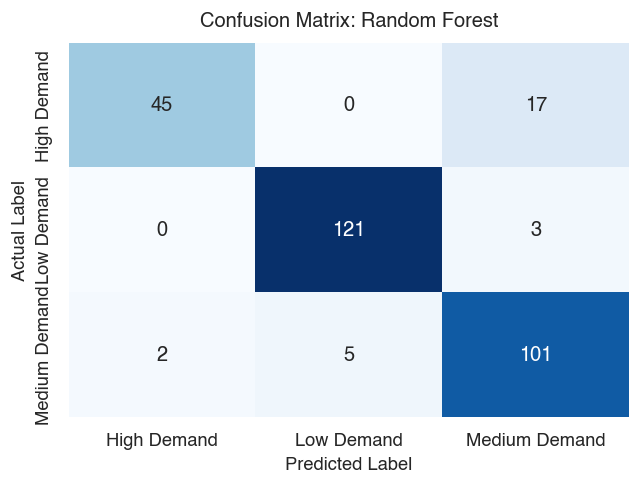

In [ ]:
# ==========================================
# 4. RANDOM FOREST CLASSIFIER
# ==========================================
# Fits Random Forest ensemble with 100 trees and max_depth=8
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
model_dict['Random Forest'] = rf_model

evaluate_model('Random Forest', y_test, y_pred_rf)

In [ ]:
# Consolidate results into a structured benchmark table
comparison_df = pd.DataFrame(results_tracker)
comparison_df = comparison_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

# Format table for student presentation
formatted_table = comparison_df.copy()
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    formatted_table[metric] = formatted_table[metric].apply(lambda x: f"{x*100:.2f}%")

print("=== FINAL MODEL PERFORMANCE COMPARISON TABLE ===")
print(formatted_table.to_string(index=False))

=== FINAL MODEL PERFORMANCE COMPARISON TABLE ===
              Model Accuracy Precision Recall F1-Score
      Random Forest   90.82%    91.36% 90.82%   90.64%
Logistic Regression   89.12%    89.11% 89.12%   89.10%
      Decision Tree   88.44%    88.33% 88.44%   88.19%
                KNN   59.18%    59.91% 59.18%   57.32%


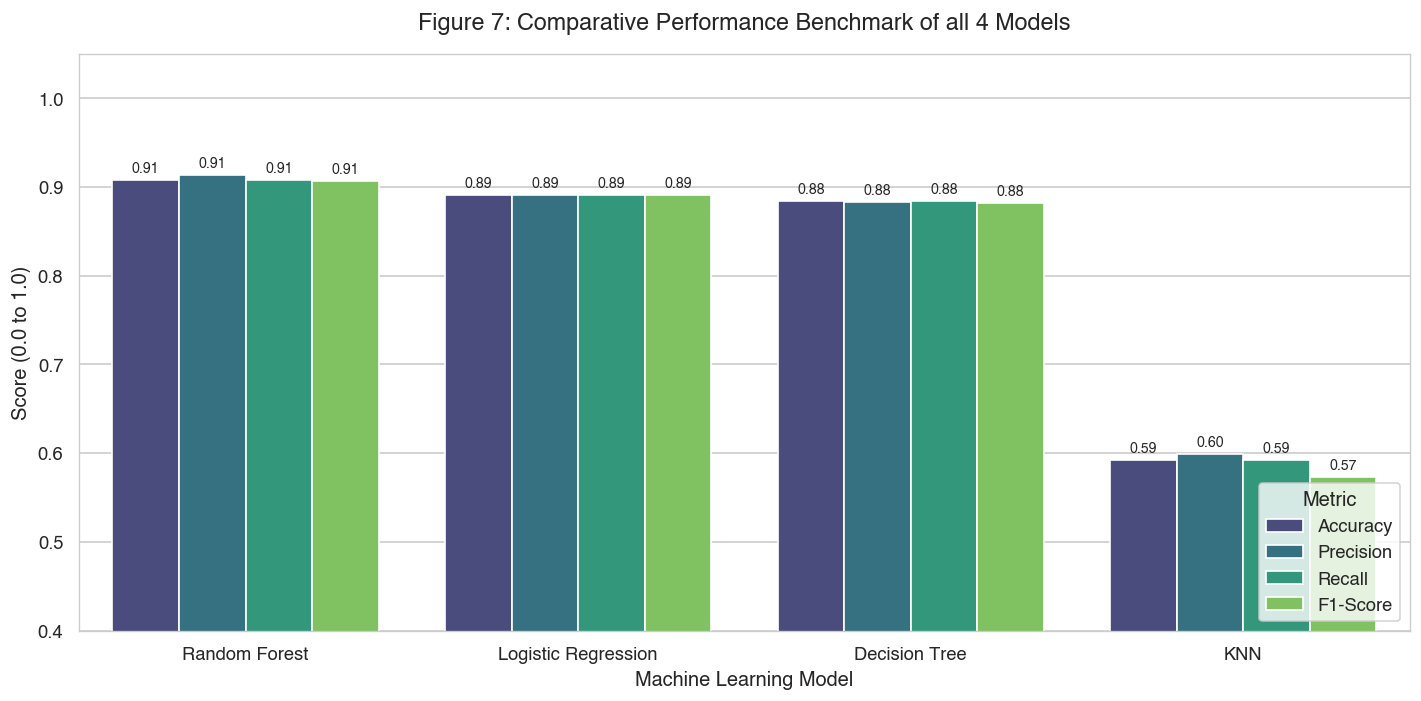

In [ ]:
# Comparative Bar Chart of all 4 Models across Metrics
plt.figure(figsize=(12, 6))
plot_df = pd.melt(comparison_df, id_vars=['Model'],
                  value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                  var_name='Metric', value_name='Score')

ax = sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Figure 7: Comparative Performance Benchmark of all 4 Models', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylim(0.4, 1.05)
plt.legend(title='Metric', loc='lower right', frameon=True)

# Annotate values above bars
for p in ax.patches:
    h = p.get_height()
    if h > 0.4:
        ax.annotate(f'{h:.2f}',
                    xy=(p.get_x() + p.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.show()

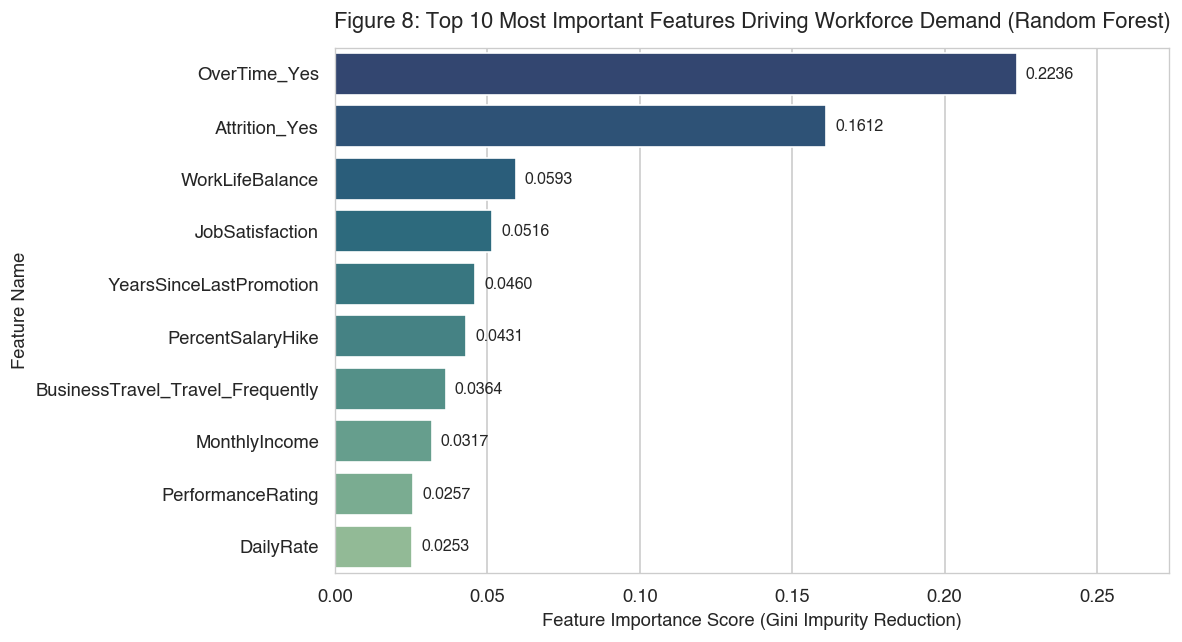

In [ ]:
# Feature importance extraction from Random Forest
rf_importances = pd.Series(
    model_dict['Random Forest'].feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

top_10 = rf_importances.head(10)

plt.figure(figsize=(10, 5.5))
sns.barplot(x=top_10.values, y=top_10.index, palette='crest_r')
plt.title('Figure 8: Top 10 Most Important Features Driving Workforce Demand (Random Forest)',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Feature Importance Score (Gini Impurity Reduction)', fontsize=11)
plt.ylabel('Feature Name', fontsize=11)

for i, v in enumerate(top_10.values):
    plt.text(v + 0.003, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9.5)

plt.xlim(0, max(top_10.values) + 0.05)
plt.tight_layout()
plt.show()

In [ ]:
# Analyze test set error distributions
test_error_analysis = pd.DataFrame({
    'Actual_Demand': y_test.values,
    'Predicted_Demand': y_pred_rf,
    'Is_Correct': (y_test.values == y_pred_rf)
})

misclassified = test_error_analysis[~test_error_analysis['Is_Correct']]

print(f"Total Test Set Samples Evaluated: {len(test_error_analysis)}")
print(f"Correctly Classified Samples     : {test_error_analysis['Is_Correct'].sum()} ({test_error_analysis['Is_Correct'].mean()*100:.2f}%)")
print(f"Total Misclassified Samples      : {len(misclassified)} ({(1-test_error_analysis['Is_Correct'].mean())*100:.2f}%)\n")

print("--- Confusion / Misclassification Crosstab ---")
print(pd.crosstab(misclassified['Actual_Demand'], misclassified['Predicted_Demand'],
                  rownames=['Actual Class'], colnames=['Misclassified As']))

Total Test Set Samples Evaluated: 294
Correctly Classified Samples     : 267 (90.82%)
Total Misclassified Samples      : 27 (9.18%)

--- Confusion / Misclassification Crosstab ---
Misclassified As  High Demand  Low Demand  Medium Demand
Actual Class                                            
High Demand                 0           0             17
Low Demand                  0           0              3
Medium Demand               2           5              0


---
### 12. Conclusion

1. **Problem Resolution:** We successfully developed and evaluated an end-to-end Machine Learning classification framework for **Workforce Demand Planning** using the IBM HR Analytics dataset.
2. **Empirical Findings:**
   - **Random Forest** proved to be the most accurate and reliable classifier (**90.82% Accuracy**, **0.9064 F1-Score**).
   - Workload stress (`OverTime`), turnover indicators (`Attrition`), work-life balance, and tenure velocity are the strongest predictors of future workforce demand.
3. **Practical Business Utility:**
   - Enables proactive talent acquisition weeks before role vacancies cause operational disruption.
   - Assists HR leadership in prioritizing recruitment budgets for high-demand roles (e.g., Sales Executives, Laboratory Technicians, Research Scientists).
   - Facilitates internal workload redistribution to curb burnout in overtime-heavy departments.